In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from enum import Enum

# ─────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────

# Example config - we will modify these values
# to test different scenarios including the
# RAID6 class of capacity failures

default_config = {
    # Queue parameters
    'n_agents': 1000,
    'max_steps': 2000,
    'width': 20,
    'height': 30,
    
    # Agent distribution
    'pct_aggressive': 0.15,
    'pct_normal': 0.25,
    
    # Cache parameters
    'cache_size': 100,
    'service_rate': 3,
    'back_pressure_threshold': 0.5,
    
    # Task definitions
    'tasks': [
        {
            'name': 'Critical',
            'requirements_known': True,
            'priority': 3.0,
            'urgency': 1.0,
            'pct_agents': 0.10
        },
        {
            'name': 'High',
            'requirements_known': True,
            'priority': 2.0,
            'urgency': 0.75,
            'pct_agents': 0.20
        },
        {
            'name': 'Normal',
            'requirements_known': False,
            'priority_min': 0.8,
            'priority_max': 1.2,
            'pct_agents': 0.50
        },
        {
            'name': 'Low',
            'requirements_known': False,
            'priority_min': 0.3,
            'priority_max': 0.7,
            'pct_agents': 0.20
        }
    ]
}

print("Configuration loaded successfully!")
print(f"Agents: {default_config['n_agents']}")
print(f"Cache size: {default_config['cache_size']}")
print(f"Service rate: {default_config['service_rate']}")
print(f"Tasks defined: {len(default_config['tasks'])}")

Configuration loaded successfully!
Agents: 1000
Cache size: 100
Service rate: 3
Tasks defined: 4


In [2]:
class PreRunAssessment:
    def __init__(self, config):
        self.config = config
        self.findings = []
        self.recommendations = []
        self.viability = None
        
    def assess_capacity(self):
        theoretical_max = (self.config['service_rate'] * 
                          self.config['max_steps'])
        demand = self.config['n_agents']
        ratio = theoretical_max / demand
        
        if ratio >= 1.2:
            status = "VIABLE"
            confidence = "HIGH"
            detail = "System well resourced for demand"
        elif ratio >= 0.9:
            status = "MARGINAL"
            confidence = "MEDIUM"
            detail = "System at capacity limits"
            self.recommendations.append(
                "Consider increasing service rate or cache size"
            )
        elif ratio >= 0.6:
            status = "STRESSED"
            confidence = "LOW"
            detail = "System under-resourced"
            self.recommendations.append(
                "Time based queuing may partially recover throughput"
            )
        else:
            status = "INFEASIBLE"
            confidence = "NONE"
            detail = "Fundamental capacity constraint detected"
            self.recommendations.append(
                "CRITICAL: Queuing optimization cannot fix this"
            )
        
        self.viability = status
        self.findings.append({
            'check': 'Capacity',
            'status': status,
            'confidence': confidence,
            'detail': detail,
            'ratio': ratio,
            'theoretical_max': theoretical_max,
            'demand': demand
        })
        return status, ratio
    
    def print_capacity_report(self):
        if not self.findings:
            self.assess_capacity()
        f = self.findings[0]
        
        print("="*60)
        print("CAPACITY ASSESSMENT")
        print("="*60)
        print(f"Agents (demand):       {f['demand']}")
        print(f"Theoretical max:       {f['theoretical_max']}")
        print(f"Capacity ratio:        {f['ratio']:.2f}")
        print(f"Status:                {f['status']}")
        print(f"Confidence:            {f['confidence']}")
        print(f"Detail:                {f['detail']}")
        
        if self.recommendations:
            print(f"\nRECOMMENDATIONS:")
            for i, rec in enumerate(self.recommendations, 1):
                print(f"  {i}. {rec}")
        
        print("="*60)
        
        if f['status'] == 'INFEASIBLE':
            print("WARNING: DO NOT PROCEED")
            print("Fix capacity constraints before simulation")
        elif f['status'] == 'STRESSED':
            print("CAUTION: PROCEED WITH AWARENESS")
            print("Results will reflect capacity constraints")
        else:
            print("CLEAR TO PROCEED WITH SIMULATION")
        print("="*60)

# Test with default config
print("Testing VIABLE scenario:")
assessment1 = PreRunAssessment(default_config)
assessment1.print_capacity_report()

Testing VIABLE scenario:
CAPACITY ASSESSMENT
Agents (demand):       1000
Theoretical max:       6000
Capacity ratio:        6.00
Status:                VIABLE
Confidence:            HIGH
Detail:                System well resourced for demand
CLEAR TO PROCEED WITH SIMULATION


In [3]:
# Test all four capacity scenarios
scenarios = [
    {
        'name': 'Optimal',
        'description': 'Well resourced system',
        'config': {**default_config,
                   'service_rate': 4,
                   'cache_size': 20}
    },
    {
        'name': 'Marginal',
        'description': '20% below optimal',
        'config': {**default_config,
                   'service_rate': 1,
                   'cache_size': 10,
                   'max_steps': 110}
    },
    {
        'name': 'Stressed',
        'description': '50% below optimal',
        'config': {**default_config,
                   'service_rate': 1,
                   'cache_size': 8,
                   'max_steps': 80}
    },
    {
        'name': 'Infeasible',
        'description': 'RAID6 class failure',
        'config': {**default_config,
                   'service_rate': 1,
                   'cache_size': 4,
                   'max_steps': 50}
    }
]

print("PRE-RUN ASSESSMENT ACROSS ALL SCENARIOS")
print("="*60)

results = []
for scenario in scenarios:
    print(f"\nScenario: {scenario['name']}")
    print(f"Description: {scenario['description']}")
    a = PreRunAssessment(scenario['config'])
    status, ratio = a.assess_capacity()
    print(f"Status: {status} | Ratio: {ratio:.2f}")
    if a.recommendations:
        for rec in a.recommendations:
            print(f"  >> {rec}")
    results.append({
        'name': scenario['name'],
        'status': status,
        'ratio': ratio
    })

# Summary table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(f"{'Scenario':<15} {'Status':<12} {'Ratio':<8} {'Proceed?'}")
print("-"*60)

for r in results:
    if r['status'] in ['VIABLE', 'MARGINAL']:
        proceed = "YES"
    elif r['status'] == 'STRESSED':
        proceed = "CAUTION"
    else:
        proceed = "NO"
    print(f"{r['name']:<15} {r['status']:<12} {r['ratio']:<8.2f} {proceed}")

print("="*60)

PRE-RUN ASSESSMENT ACROSS ALL SCENARIOS

Scenario: Optimal
Description: Well resourced system
Status: VIABLE | Ratio: 8.00

Scenario: Marginal
Description: 20% below optimal
Status: INFEASIBLE | Ratio: 0.11
  >> CRITICAL: Queuing optimization cannot fix this

Scenario: Stressed
Description: 50% below optimal
Status: INFEASIBLE | Ratio: 0.08
  >> CRITICAL: Queuing optimization cannot fix this

Scenario: Infeasible
Description: RAID6 class failure
Status: INFEASIBLE | Ratio: 0.05
  >> CRITICAL: Queuing optimization cannot fix this

SUMMARY TABLE
Scenario        Status       Ratio    Proceed?
------------------------------------------------------------
Optimal         VIABLE       8.00     YES
Marginal        INFEASIBLE   0.11     NO
Stressed        INFEASIBLE   0.08     NO
Infeasible      INFEASIBLE   0.05     NO


In [4]:
def assess_task_weights(config):
    """
    Assigns priority weights to agent tasks.
    Known requirements get precise weights.
    Unknown requirements get probability distributions.
    Directly addresses assumption uncertainty.
    """
    weights = {}
    unknowns = []
    knowns = []
    
    print("="*60)
    print("TASK WEIGHT ASSIGNMENT")
    print("="*60)
    
    for task in config.get('tasks', []):
        name = task['name']
        
        if task['requirements_known']:
            # Precise weight - high confidence
            weights[name] = {
                'priority': task['priority'],
                'urgency': task['urgency'],
                'pct_agents': task['pct_agents'],
                'confidence': 'HIGH',
                'type': 'KNOWN'
            }
            knowns.append(name)
        else:
            # Statistical weight - low confidence
            # Sample from uniform distribution
            sampled_priority = np.random.uniform(
                task['priority_min'],
                task['priority_max']
            )
            sampled_urgency = np.random.uniform(0.5, 1.0)
            
            weights[name] = {
                'priority': sampled_priority,
                'urgency': sampled_urgency,
                'pct_agents': task['pct_agents'],
                'confidence': 'LOW',
                'type': 'ESTIMATED',
                'priority_range': (
                    task['priority_min'],
                    task['priority_max']
                )
            }
            unknowns.append(name)
    
    # Print assignment table
    print(f"\n{'Task':<12} {'Type':<10} {'Priority':<10} "
          f"{'Urgency':<10} {'Agents%':<10} {'Confidence'}")
    print("-"*60)
    
    for name, w in weights.items():
        pct = f"{w['pct_agents']*100:.0f}%"
        if w['type'] == 'ESTIMATED':
            pri = f"{w['priority']:.2f}*"
            urg = f"{w['urgency']:.2f}*"
        else:
            pri = f"{w['priority']:.2f}"
            urg = f"{w['urgency']:.2f}"
        print(f"{name:<12} {w['type']:<10} {pri:<10} "
              f"{urg:<10} {pct:<10} {w['confidence']}")
    
    print("\n* = estimated from probability distribution")
    
    # Flag unknowns as risk
    if unknowns:
        print(f"\nUNKNOWN REQUIREMENTS DETECTED: {unknowns}")
        print("These tasks have estimated weights only.")
        print("Results sensitive to these assumptions.")
        print("RECOMMENDATION: Measure or define these")
        print("requirements before production deployment.")
    else:
        print("\nAll task requirements known - HIGH confidence")
    
    print("="*60)
    return weights

# Run task weight assessment
weights = assess_task_weights(default_config)

TASK WEIGHT ASSIGNMENT

Task         Type       Priority   Urgency    Agents%    Confidence
------------------------------------------------------------
Critical     KNOWN      3.00       1.00       10%        HIGH
High         KNOWN      2.00       0.75       20%        HIGH
Normal       ESTIMATED  1.12*      0.57*      50%        LOW
Low          ESTIMATED  0.55*      0.84*      20%        LOW

* = estimated from probability distribution

UNKNOWN REQUIREMENTS DETECTED: ['Normal', 'Low']
These tasks have estimated weights only.
Results sensitive to these assumptions.
RECOMMENDATION: Measure or define these
requirements before production deployment.


SENSITIVITY ANALYSIS
Running 50 samples per parameter...
Baseline throughput estimate: 117000.0

Parameter                    Risk     Mean Impact    Max Impact
------------------------------------------------------------
cache_size                   HIGH     87.9%          94.9%
service_rate                 HIGH     29.2%          62.5%
back_pressure_threshold      MEDIUM   10.9%          19.9%
pct_aggressive               MEDIUM   10.3%          22.1%

MEASUREMENT PRIORITIES:
Focus effort on HIGH risk parameters first
------------------------------------------------------------
  1. HIGH RISK: cache_size
     Range tested: (5, 20)
     Mean impact:  87.9%
     Max impact:   94.9%
  2. HIGH RISK: service_rate
     Range tested: (1, 5)
     Mean impact:  29.2%
     Max impact:   62.5%
  3. MEDIUM RISK: back_pressure_threshold
     Range tested: (0.2, 0.8)
     Mean impact:  10.9%
     Max impact:   19.9%
  4. MEDIUM RISK: pct_aggressive
     Range tested: (0.05, 0.3)
     Mean impact: 

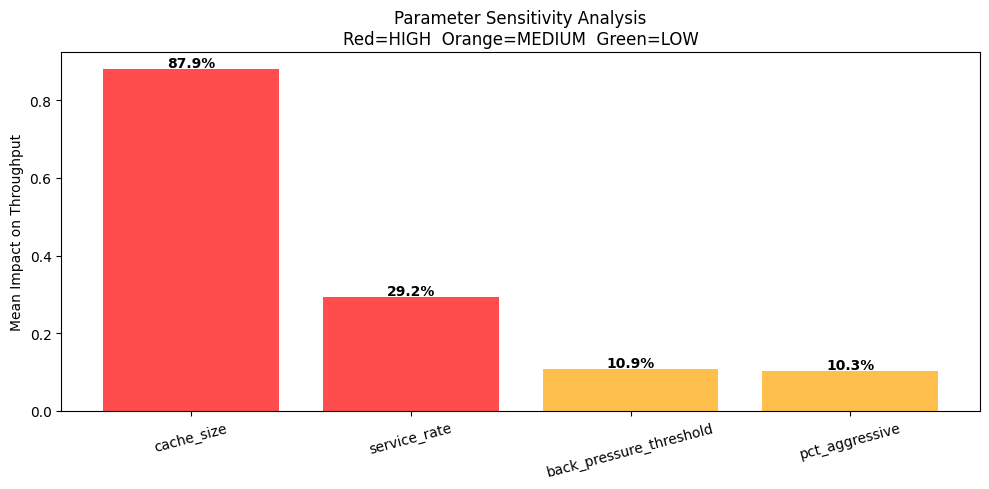


Chart saved as sensitivity_analysis.png


In [5]:
def sensitivity_analysis(config, weights, n_samples=50):
    """
    Tests which parameters have highest impact.
    Uses uncapped throughput estimate to show real variation.
    """
    print("="*60)
    print("SENSITIVITY ANALYSIS")
    print("="*60)
    print(f"Running {n_samples} samples per parameter...")
    
    # Parameters to test with ranges
    test_params = {
        'pct_aggressive': (0.05, 0.30),
        'cache_size': (5, 20),
        'service_rate': (1, 5),
        'back_pressure_threshold': (0.2, 0.8)
    }
    
    # Uncapped throughput estimate
    def estimate_throughput(cfg):
        # Base throughput from service rate
        base = cfg['service_rate'] * cfg['max_steps']
        
        # Aggression bonus - more aggressive = faster
        aggression_bonus = 1.0 + (cfg['pct_aggressive'] * 2.0)
        
        # Cache factor - larger cache = smoother flow
        cache_factor = cfg['cache_size'] / 10.0
        
        # Back pressure efficiency
        bp_factor = 1.0 + cfg['back_pressure_threshold']
        
        # Combined estimate - not capped
        return base * aggression_bonus * cache_factor * bp_factor
    
    baseline = estimate_throughput(config)
    print(f"Baseline throughput estimate: {baseline:.1f}")
    sensitivities = {}
    
    for param, (low, high) in test_params.items():
        impacts = []
        
        for _ in range(n_samples):
            test_val = np.random.uniform(low, high)
            test_config = {**config, param: test_val}
            throughput = estimate_throughput(test_config)
            impact = abs(throughput - baseline) / baseline
            impacts.append(impact)
        
        mean_impact = np.mean(impacts)
        max_impact = np.max(impacts)
        
        if mean_impact > 0.20:
            risk = "HIGH"
        elif mean_impact > 0.10:
            risk = "MEDIUM"
        else:
            risk = "LOW"
            
        sensitivities[param] = {
            'mean_impact': mean_impact,
            'max_impact': max_impact,
            'risk': risk,
            'range': (low, high)
        }
    
    # Sort by impact
    sorted_params = sorted(
        sensitivities.items(),
        key=lambda x: x[1]['mean_impact'],
        reverse=True
    )
    
    # Print table
    print(f"\n{'Parameter':<28} {'Risk':<8} "
          f"{'Mean Impact':<14} {'Max Impact'}")
    print("-"*60)
    
    for param, s in sorted_params:
        print(f"{param:<28} {s['risk']:<8} "
              f"{s['mean_impact']:.1%}          "
              f"{s['max_impact']:.1%}")
    
    # Recommendations
    print("\nMEASUREMENT PRIORITIES:")
    print("Focus effort on HIGH risk parameters first")
    print("-"*60)
    
    priority = 1
    for param, s in sorted_params:
        if s['risk'] in ['HIGH', 'MEDIUM']:
            print(f"  {priority}. {s['risk']} RISK: {param}")
            print(f"     Range tested: {s['range']}")
            print(f"     Mean impact:  {s['mean_impact']:.1%}")
            print(f"     Max impact:   {s['max_impact']:.1%}")
            priority += 1
    
    if priority == 1:
        print("  No significant risk parameters detected")
        print("  Model robust to parameter variation")
    
    # Visualize sensitivity
    params = [p for p, _ in sorted_params]
    mean_impacts = [s['mean_impact'] for _, s in sorted_params]
    colors = []
    for _, s in sorted_params:
        if s['risk'] == 'HIGH':
            colors.append('red')
        elif s['risk'] == 'MEDIUM':
            colors.append('orange')
        else:
            colors.append('green')
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(params, mean_impacts, color=colors, alpha=0.7)
    plt.ylabel('Mean Impact on Throughput')
    plt.title('Parameter Sensitivity Analysis\n'
              'Red=HIGH  Orange=MEDIUM  Green=LOW')
    plt.xticks(rotation=15)
    
    for bar, impact in zip(bars, mean_impacts):
        plt.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{impact:.1%}',
                ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('sensitivity_analysis.png', dpi=150)
    plt.show()
    print("\nChart saved as sensitivity_analysis.png")
    print("="*60)
    
    return sensitivities

# Run sensitivity analysis
sensitivities = sensitivity_analysis(default_config, weights)

BUNCH QUEUE MODEL - FULL PRE-RUN ASSESSMENT

PHASE 1: CAPACITY ASSESSMENT
Result: VIABLE (ratio: 6.00)

PHASE 2: TASK WEIGHT ASSIGNMENT
TASK WEIGHT ASSIGNMENT

Task         Type       Priority   Urgency    Agents%    Confidence
------------------------------------------------------------
Critical     KNOWN      3.00       1.00       10%        HIGH
High         KNOWN      2.00       0.75       20%        HIGH
Normal       ESTIMATED  1.08*      0.66*      50%        LOW
Low          ESTIMATED  0.52*      0.77*      20%        LOW

* = estimated from probability distribution

UNKNOWN REQUIREMENTS DETECTED: ['Normal', 'Low']
These tasks have estimated weights only.
Results sensitive to these assumptions.
RECOMMENDATION: Measure or define these
requirements before production deployment.

Known requirements:   30% of agents
Unknown requirements: 70% of agents

PHASE 3: SENSITIVITY ANALYSIS
SENSITIVITY ANALYSIS
Running 50 samples per parameter...
Baseline throughput estimate: 117000.0

Param

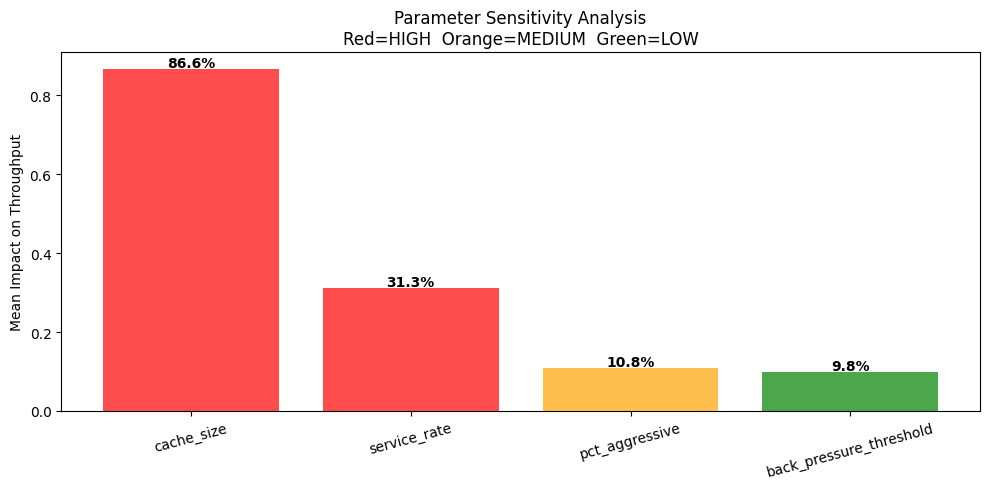


Chart saved as sensitivity_analysis.png

FINAL PRE-RUN RECOMMENDATION
Capacity Status:      VIABLE
Known requirements:   30%
High risk params:     ['cache_size', 'service_rate']
Medium risk params:   ['pct_aggressive']

Overall Confidence:   LOW
Recommendation:       PROCEED WITH CAUTION
Reason:               High uncertainty in parameters

BEFORE PROCEEDING - VERIFY:
  1. cache_size
     Max impact: 94.9%
     Range: (5, 20)
  2. service_rate
     Max impact: 65.5%
     Range: (1, 5)


In [6]:
def full_prerun_report(config):
    """
    Complete pre-run assessment combining:
    1. Capacity assessment
    2. Task weight assignment  
    3. Sensitivity analysis
    Generates go/no-go recommendation with confidence level
    """
    print("="*60)
    print("BUNCH QUEUE MODEL - FULL PRE-RUN ASSESSMENT")
    print("="*60)
    
    # Phase 1 - Capacity
    print("\nPHASE 1: CAPACITY ASSESSMENT")
    assessment = PreRunAssessment(config)
    status, ratio = assessment.assess_capacity()
    print(f"Result: {status} (ratio: {ratio:.2f})")
    
    # Phase 2 - Task weights
    print("\nPHASE 2: TASK WEIGHT ASSIGNMENT")
    weights = assess_task_weights(config)
    
    # Count known vs unknown
    known_pct = sum(
        t['pct_agents'] for t in config['tasks']
        if t['requirements_known']
    )
    unknown_pct = 1.0 - known_pct
    print(f"\nKnown requirements:   {known_pct*100:.0f}% of agents")
    print(f"Unknown requirements: {unknown_pct*100:.0f}% of agents")
    
    # Phase 3 - Sensitivity
    print("\nPHASE 3: SENSITIVITY ANALYSIS")
    sensitivities = sensitivity_analysis(config, weights)
    
    high_risk = [p for p, s in sensitivities.items() 
                 if s['risk'] == 'HIGH']
    medium_risk = [p for p, s in sensitivities.items() 
                   if s['risk'] == 'MEDIUM']
    
    # Final recommendation
    print("\n" + "="*60)
    print("FINAL PRE-RUN RECOMMENDATION")
    print("="*60)
    
    # Determine overall confidence
    if status == 'INFEASIBLE':
        confidence = 'NONE'
        recommendation = 'DO NOT PROCEED'
        reason = 'Fundamental capacity constraint'
    elif status == 'STRESSED' or unknown_pct > 0.5:
        confidence = 'LOW'
        recommendation = 'PROCEED WITH CAUTION'
        reason = 'High uncertainty in parameters'
    elif high_risk and unknown_pct > 0.3:
        confidence = 'MEDIUM'
        recommendation = 'PROCEED - VERIFY HIGH RISK PARAMS'
        reason = 'Some parameters need verification'
    else:
        confidence = 'HIGH'
        recommendation = 'PROCEED WITH SIMULATION'
        reason = 'System well characterized'
    
    print(f"Capacity Status:      {status}")
    print(f"Known requirements:   {known_pct*100:.0f}%")
    print(f"High risk params:     {high_risk}")
    print(f"Medium risk params:   {medium_risk}")
    print(f"\nOverall Confidence:   {confidence}")
    print(f"Recommendation:       {recommendation}")
    print(f"Reason:               {reason}")
    
    if high_risk:
        print(f"\nBEFORE PROCEEDING - VERIFY:")
        for i, param in enumerate(high_risk, 1):
            s = sensitivities[param]
            print(f"  {i}. {param}")
            print(f"     Max impact: {s['max_impact']:.1%}")
            print(f"     Range: {s['range']}")
    
    print("="*60)
    
    return {
        'status': status,
        'confidence': confidence,
        'recommendation': recommendation,
        'weights': weights,
        'sensitivities': sensitivities
    }

# Run full pre-run report
report = full_prerun_report(default_config)